# Exp 17 — EDA пар: анализ выхода `04_synth_pairs.py`

**Что смотрим:**
1. Обзор всех сформированных датасетов (размеры, pos/neg баланс)
2. Покрытие колонок: что есть в A, что в B, пересечение
3. NaN-паттерны — особенно ламода после `min_notnull` фильтра
4. Качество позитивных пар — насколько похожи A и B записи
5. Примеры пар (позитивные и негативные)


In [1]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ── Пути ──────────────────────────────────────────────────────────────
ROOT = Path("../..").resolve()
SYNTH = ROOT / "data" / "synthetic"

DATASETS = ["auto_ru", "ozon", "lamoda", "cars_ru", "devices"]

def load_dataset(name: str) -> dict | None:
    d = SYNTH / name
    if not d.exists():
        return None
    ta = pd.read_csv(d / "tableA_synth.csv")
    tb = pd.read_csv(d / "tableB_synth.csv")
    train = pd.read_csv(d / "train.csv")
    valid = pd.read_csv(d / "valid.csv")
    test  = pd.read_csv(d / "test.csv")
    stats = json.loads((d / "stats.json").read_text()) if (d / "stats.json").exists() else {}
    return {"name": name, "A": ta, "B": tb, "train": train, "valid": valid, "test": test, "stats": stats}

dsets = {n: ds for n in DATASETS if (ds := load_dataset(n)) is not None}
print(f"Загружено датасетов: {list(dsets)}")


/tmp/ipykernel_3591492/1226076548.py:21: DtypeWarning: Columns (36,37,38,41,45,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  ta = pd.read_csv(d / "tableA_synth.csv")
/tmp/ipykernel_3591492/1226076548.py:22: DtypeWarning: Columns (30,31,43,45) have mixed types. Specify dtype option on import or set low_memory=False.
  tb = pd.read_csv(d / "tableB_synth.csv")
/tmp/ipykernel_3591492/1226076548.py:21: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  ta = pd.read_csv(d / "tableA_synth.csv")


Загружено датасетов: ['auto_ru', 'ozon', 'lamoda', 'cars_ru', 'devices']


---
## 1. Обзор датасетов


In [2]:
rows = []
for name, ds in dsets.items():
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    n_pos = int(labeled["label"].sum())
    n_neg = len(labeled) - n_pos
    cols_a = [c for c in ds["A"].columns if c != "id"]
    cols_b = [c for c in ds["B"].columns if c != "id"]
    shared = len(set(cols_a) & set(cols_b))
    rows.append({
        "датасет":     name,
        "строк A":     len(ds["A"]),
        "строк B":     len(ds["B"]),
        "колонок A":   len(cols_a),
        "колонок B":   len(cols_b),
        "общих колонок": shared,
        "позитивов":   n_pos,
        "негативов":   n_neg,
        "pos/neg":     f"1:{n_neg // max(n_pos, 1)}",
        "train":       len(ds["train"]),
        "val":         len(ds["valid"]),
        "test":        len(ds["test"]),
    })

overview = pd.DataFrame(rows).set_index("датасет")
overview


,строк A,строк B,колонок A,колонок B,общих колонок,позитивов,негативов,pos/neg,train,val,test
датасет,,,,,,,,,,,
auto_ru,70896,75790,379,389,365,16955,84775,1:5,71212,15259,15259
ozon,117025,114882,12,12,12,33414,167070,1:5,140340,30072,30072
lamoda,10317,10317,50,50,50,10317,51585,1:5,43332,9285,9285
cars_ru,100000,100000,180,148,125,100000,500000,1:5,420000,90000,90000
devices,15000,15000,15,12,10,15000,75000,1:5,63000,13500,13500


/tmp/ipykernel_3591492/3215767978.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=20)


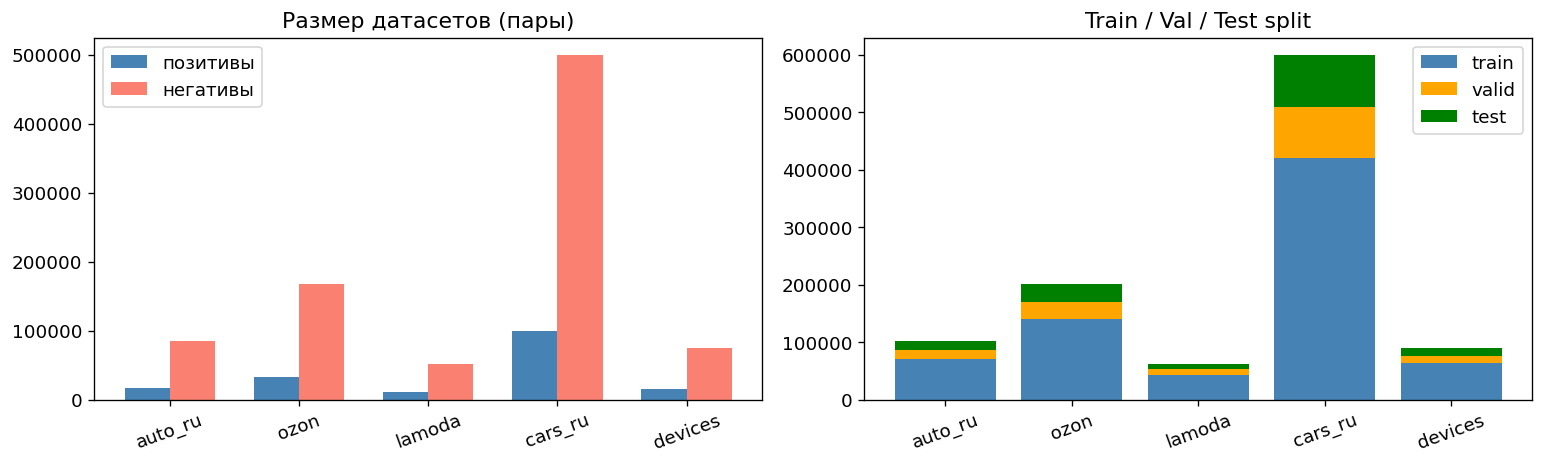

In [3]:
# Pos/neg баланс — гистограмма
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = list(dsets)
positives = [int(pd.concat([ds["train"], ds["valid"], ds["test"]])["label"].sum()) for ds in dsets.values()]
negatives = [len(pd.concat([ds["train"], ds["valid"], ds["test"]])) - p for ds, p in zip(dsets.values(), positives)]

x = np.arange(len(names))
w = 0.35
axes[0].bar(x - w/2, positives, w, label="позитивы", color="steelblue")
axes[0].bar(x + w/2, negatives, w, label="негативы", color="salmon")
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20)
axes[0].set_title("Размер датасетов (пары)")
axes[0].legend()

# Train / val / test split
train_s = [len(ds["train"]) for ds in dsets.values()]
val_s   = [len(ds["valid"]) for ds in dsets.values()]
test_s  = [len(ds["test"])  for ds in dsets.values()]
bottom_tv = np.array(train_s)
bottom_vt = bottom_tv + np.array(val_s)
axes[1].bar(names, train_s, label="train", color="steelblue")
axes[1].bar(names, val_s,   bottom=bottom_tv, label="valid", color="orange")
axes[1].bar(names, test_s,  bottom=bottom_vt, label="test",  color="green")
axes[1].set_xticklabels(names, rotation=20)
axes[1].set_title("Train / Val / Test split")
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 2. Покрытие колонок: A vs B

Для каждого датасета смотрим:
- Какие колонки только в A, только в B, в обеих
- Jaccard(A, B) — чем выше, тем больше схемы совпадают


In [4]:
col_rows = []
for name, ds in dsets.items():
    ca = set(c for c in ds["A"].columns if c != "id")
    cb = set(c for c in ds["B"].columns if c != "id")
    only_a = ca - cb
    only_b = cb - ca
    shared = ca & cb
    jaccard = len(shared) / len(ca | cb) if ca | cb else 0
    col_rows.append({
        "датасет": name,
        "только в A": len(only_a),
        "только в B": len(only_b),
        "общие": len(shared),
        "Jaccard": round(jaccard, 3),
        "примеры только A": sorted(only_a)[:4],
        "примеры только B": sorted(only_b)[:4],
    })

col_df = pd.DataFrame(col_rows).set_index("датасет")
display(col_df[["только в A", "только в B", "общие", "Jaccard"]])

print()
for _, r in col_df.iterrows():
    print(f"{r.name}")
    if r["примеры только A"]: print(f"  только A: {r['примеры только A']}")
    if r["примеры только B"]: print(f"  только B: {r['примеры только B']}")


,только в A,только в B,общие,Jaccard
датасет,,,,
auto_ru,14,24,365,0.906
ozon,0,0,12,1.000
lamoda,0,0,50,1.000
cars_ru,55,23,125,0.616
devices,5,2,10,0.588



auto_ru
  только A: ['car_url', 'equip_24-inch-wheels', 'equip_8RM', 'equip_E0P']
  только B: ['equip_033GQ', 'equip_033IN', 'equip_041CZ', 'equip_066AC']
ozon
lamoda
cars_ru
  только A: ['body_type', 'city', 'description', 'drive_type']
  только B: ['condition', 'opt_15-inch-wheels', 'opt_20-inch-wheels', 'opt_adj-pedals']
devices
  только A: ['device_model', 'start_year', 'technical_specs.connection', 'technical_specs.dpi']
  только B: ['model_family', 'technical_specs.ports']


---
## 3. NaN-паттерны: заполненность таблиц A и B


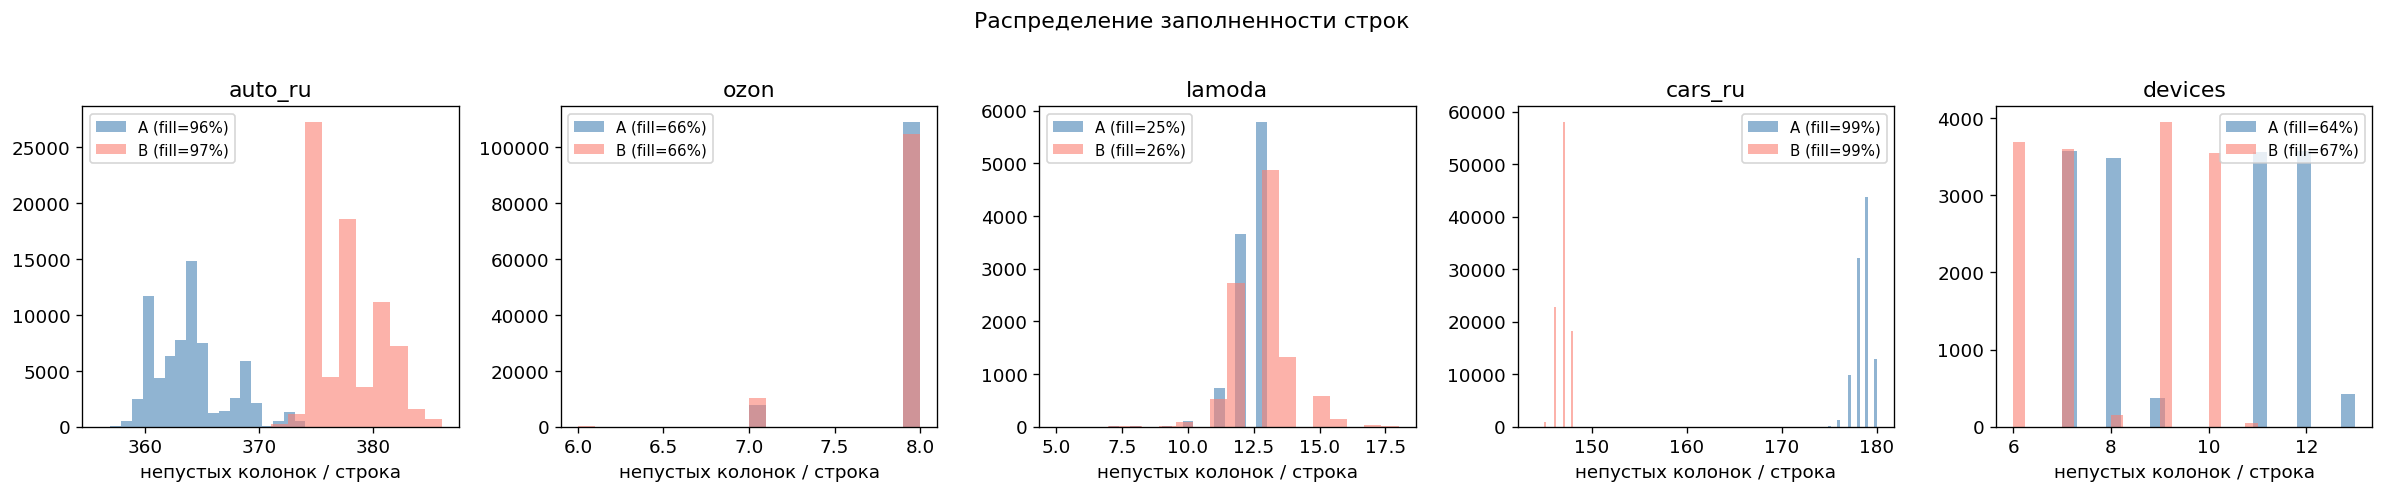

In [5]:
fig, axes = plt.subplots(1, len(dsets), figsize=(4 * len(dsets), 4), sharey=False)
if len(dsets) == 1:
    axes = [axes]

for ax, (name, ds) in zip(axes, dsets.items()):
    fa = [c for c in ds["A"].columns if c != "id"]
    fb = [c for c in ds["B"].columns if c != "id"]
    fill_a = ds["A"][fa].notna().mean().mean()
    fill_b = ds["B"][fb].notna().mean().mean()
    # Распределение "непустых колонок на строку"
    notnull_a = ds["A"][fa].notna().sum(axis=1)
    notnull_b = ds["B"][fb].notna().sum(axis=1)
    ax.hist(notnull_a, bins=20, alpha=0.6, label=f"A (fill={fill_a:.0%})", color="steelblue")
    ax.hist(notnull_b, bins=20, alpha=0.6, label=f"B (fill={fill_b:.0%})", color="salmon")
    ax.set_title(name)
    ax.set_xlabel("непустых колонок / строка")
    ax.legend(fontsize=9)

plt.suptitle("Распределение заполненности строк", y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Качество позитивных пар: расхождение значений A vs B

Для каждой позитивной пары (одна сущность) берём общие колонки и смотрим,
в каком % ячеек значения отличаются. Это measure of "difficulty":
- Низкое расхождение → пара слишком лёгкая (trivial positive)
- Высокое расхождение → value corruption работает


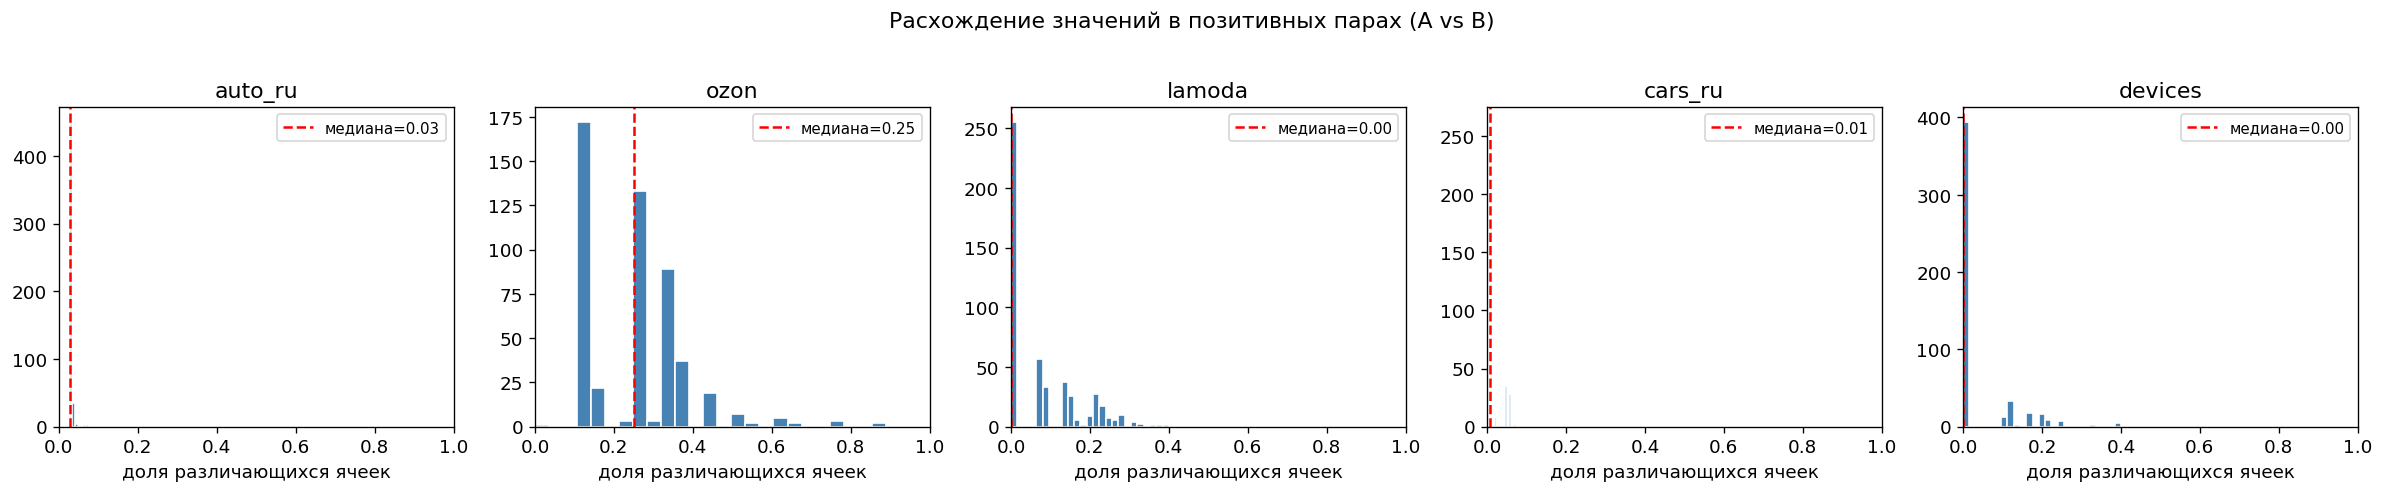

In [6]:
def value_divergence(ds: dict, n_sample: int = 500) -> pd.Series:
    """Для каждой позитивной пары: доля общих ячеек с разными значениями."""
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    pos = labeled[labeled["label"] == 1].head(n_sample)

    ta = ds["A"].set_index("id")
    tb = ds["B"].set_index("id")
    shared_cols = [c for c in ta.columns if c in tb.columns]
    if not shared_cols:
        return pd.Series([], dtype=float)

    divs = []
    for _, row in pos.iterrows():
        a_id, b_id = int(row["ltable_id"]), int(row["rtable_id"])
        if a_id not in ta.index or b_id not in tb.index:
            continue
        ra = ta.loc[a_id, shared_cols].astype(str)
        rb = tb.loc[b_id, shared_cols].astype(str)
        # Считаем только непустые ячейки хотя бы в одной стороне
        mask = (ra != "nan") | (rb != "nan")
        if mask.sum() == 0:
            continue
        diff = (ra[mask] != rb[mask]).mean()
        divs.append(diff)
    return pd.Series(divs)

fig, axes = plt.subplots(1, len(dsets), figsize=(4 * len(dsets), 4), sharey=False)
if len(dsets) == 1:
    axes = [axes]

for ax, (name, ds) in zip(axes, dsets.items()):
    divs = value_divergence(ds)
    if divs.empty:
        ax.text(0.5, 0.5, "нет общих колонок", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.hist(divs, bins=25, color="steelblue", edgecolor="white")
        ax.axvline(divs.median(), color="red", linestyle="--", label=f"медиана={divs.median():.2f}")
        ax.legend(fontsize=9)
    ax.set_title(name)
    ax.set_xlabel("доля различающихся ячеек")
    ax.set_xlim(0, 1)

plt.suptitle("Расхождение значений в позитивных парах (A vs B)", y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Примеры пар

Показываем по 3 позитивных и 3 негативных пары для каждого датасета.


In [7]:
def show_pairs(name: str, ds: dict, n: int = 3) -> None:
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    ta = ds["A"].set_index("id")
    tb = ds["B"].set_index("id")
    shared_cols = [c for c in ta.columns if c in tb.columns]
    # Предпочитаем содержательные колонки (не числовые id-like)
    show_cols = shared_cols[:8]

    for label_val, label_name in [(1, "ПОЗИТИВНЫЕ"), (0, "НЕГАТИВНЫЕ")]:
        subset = labeled[labeled["label"] == label_val].head(n)
        print(f"\n{'='*60}")
        print(f"{name.upper()} — {label_name} пары (label={label_val})")
        print(f"{'='*60}")
        for i, (_, row) in enumerate(subset.iterrows()):
            a_id, b_id = int(row["ltable_id"]), int(row["rtable_id"])
            if a_id not in ta.index or b_id not in tb.index:
                continue
            ra = ta.loc[a_id, show_cols]
            rb = tb.loc[b_id, show_cols]
            pair_df = pd.DataFrame({"A": ra, "B": rb})
            pair_df["≠"] = pair_df.apply(
                lambda r: "✗" if str(r["A"]) != str(r["B"]) and str(r["A"]) != "nan" and str(r["B"]) != "nan" else "", axis=1
            )
            print(f"\n  Пара {i+1}  (ltable_id={a_id}, rtable_id={b_id})")
            print(pair_df.to_string())

for name, ds in dsets.items():
    show_pairs(name, ds)



AUTO_RU — ПОЗИТИВНЫЕ пары (label=1)

  Пара 1  (ltable_id=15204, rtable_id=24913)
                                                                                                                                                                                    A                                                                                                                                                                  B  ≠
bodyType                                                                                                                                                            внедорожник 5 дв.                                                                                                                                                  Внедорожник 5 дв.  ✗
brand                                                                                                                                                                        INFINITI                                        

---
## 6. Ламода: NaN-профили и эффект `min_notnull`


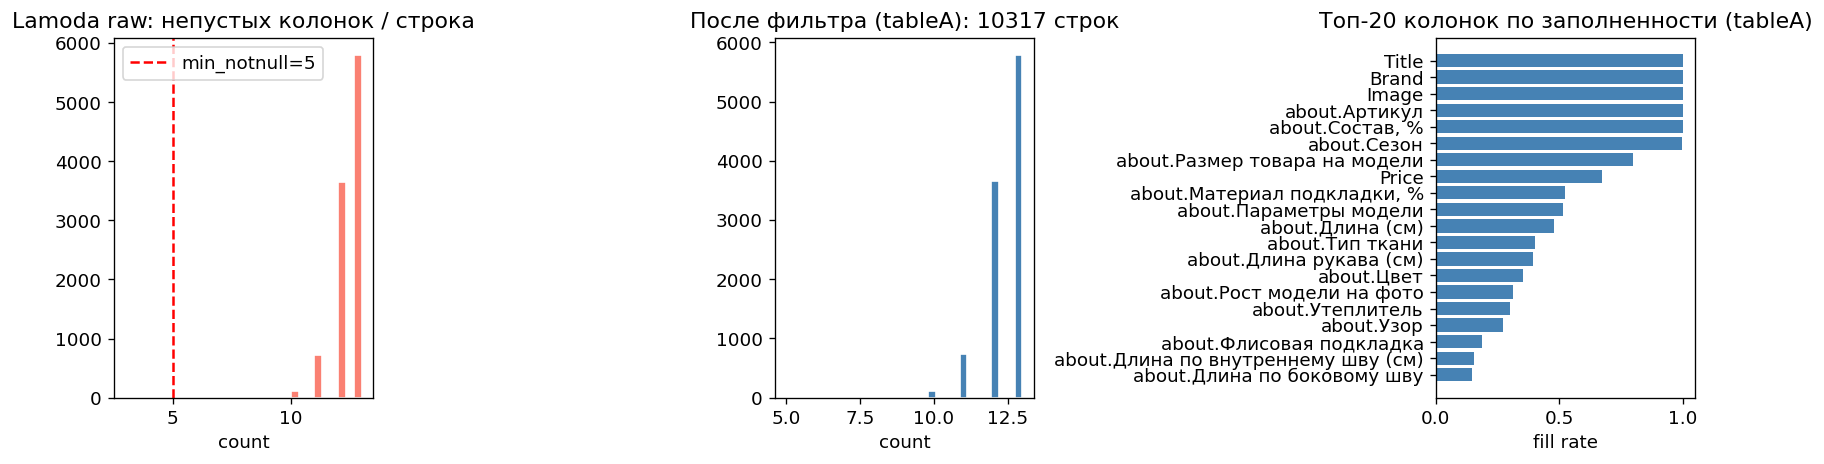

Raw строк: 10338, после min_notnull=5: 10317 (100% остаётся)


In [8]:
RAW_RU = ROOT / "data" / "raw_ru"

if "lamoda" in dsets:
    raw_lam_path = RAW_RU / "lamoda" / "clean.parquet"
    if raw_lam_path.exists():
        raw_lam = pd.read_parquet(raw_lam_path)
        feat_cols = [c for c in raw_lam.columns if c != "id"]
        notnull_raw = raw_lam[feat_cols].notna().sum(axis=1)
        notnull_filt = dsets["lamoda"]["A"][[c for c in dsets["lamoda"]["A"].columns if c != "id"]].notna().sum(axis=1)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))

        axes[0].hist(notnull_raw, bins=30, color="salmon", edgecolor="white")
        axes[0].axvline(5, color="red", linestyle="--", label="min_notnull=5")
        axes[0].set_title("Lamoda raw: непустых колонок / строка")
        axes[0].set_xlabel("count")
        axes[0].legend()

        axes[1].hist(notnull_filt, bins=30, color="steelblue", edgecolor="white")
        axes[1].set_title(f"После фильтра (tableA): {len(dsets['lamoda']['A'])} строк")
        axes[1].set_xlabel("count")

        # Топ-20 колонок по заполненности в tableA
        lam_a = dsets["lamoda"]["A"]
        fill_per_col = lam_a[[c for c in lam_a.columns if c != "id"]].notna().mean().sort_values(ascending=False).head(20)
        axes[2].barh(fill_per_col.index[::-1], fill_per_col.values[::-1], color="steelblue")
        axes[2].set_title("Топ-20 колонок по заполненности (tableA)")
        axes[2].set_xlabel("fill rate")

        plt.tight_layout()
        plt.show()

        print(f"Raw строк: {len(raw_lam)}, после min_notnull=5: {len(dsets['lamoda']['A'])} "
              f"({len(dsets['lamoda']['A'])/len(raw_lam):.0%} остаётся)")
    else:
        print("clean.parquet ламоды не найден — анализ сырых данных пропускаем")
else:
    print("Датасет lamoda не загружен")


---
## 7. Итог — сводная таблица


In [9]:
summary_rows = []
for name, ds in dsets.items():
    labeled = pd.concat([ds["train"], ds["valid"], ds["test"]])
    n_pos = int(labeled["label"].sum())
    n_neg = len(labeled) - n_pos
    ca = set(c for c in ds["A"].columns if c != "id")
    cb = set(c for c in ds["B"].columns if c != "id")
    jaccard = len(ca & cb) / len(ca | cb) if ca | cb else 0
    divs = value_divergence(ds, n_sample=200)
    median_div = divs.median() if not divs.empty else float("nan")
    kind = "natural" if name in ("auto_ru", "ozon") else "synthetic"
    summary_rows.append({
        "датасет": name,
        "тип": kind,
        "позитивов": n_pos,
        "neg/pos": round(n_neg / max(n_pos, 1), 1),
        "Jaccard(cols)": round(jaccard, 2),
        "медиана расхождения": round(median_div, 2) if not np.isnan(median_div) else "—",
        "оценка качества": (
            "✓ реальные" if kind == "natural"
            else "⚠ trivial" if median_div < 0.05
            else "✓ OK"
        ),
    })

summary = pd.DataFrame(summary_rows).set_index("датасет")
display(summary)
print("\nПримечание: 'trivial' = позитивные пары почти идентичны → лёгкая задача для модели")


,тип,позитивов,neg/pos,Jaccard(cols),медиана расхождения,оценка качества
датасет,,,,,,
auto_ru,natural,16955,5.0,0.91,0.03,✓ реальные
ozon,natural,33414,5.0,1.00,0.25,✓ реальные
lamoda,synthetic,10317,5.0,1.00,0.00,⚠ trivial
cars_ru,synthetic,100000,5.0,0.62,0.01,⚠ trivial
devices,synthetic,15000,5.0,0.59,0.00,⚠ trivial



Примечание: 'trivial' = позитивные пары почти идентичны → лёгкая задача для модели
